# 1. Análise Analítica de Seção Elíptica 2D (Modos TE e TM)

Este notebook calcula os parâmetros fundamentais de um guia de ondas elíptico 2D. A geometria exige a mudança do sistema de coordenadas cartesianas para o sistema de coordenadas elípticas $(\xi, \eta)$.

A elipse é definida pelo semi-eixo maior ($a$) e semi-eixo menor ($b$). A distância focal $f$ é dada por $f = \sqrt{a^2 - b^2}$. A fronteira metálica do guia ocorre na coordenada radial elíptica constante $\xi_0 = \text{acosh}(a/f)$.

## 1.1 Frequência de Corte e Funções de Mathieu

As equações de onda em coordenadas elípticas resultam nas **Funções de Mathieu**. Os modos são divididos em pares (even) e ímpares (odd). Focaremos nos modos pares, denotados como $eTE_{mn}$ e $eTM_{mn}$:
* **$m$**: Ordem da função angular de Mathieu (variações azimutais).
* **$n$**: Índice da raiz da função radial modificada de Mathieu.

A frequência de corte é governada pelo parâmetro estrutural $q = \left(\frac{k_c f}{2}\right)^2$. 
Ao contrário do guia circular (onde as raízes são fixas), no guia elíptico o valor de $q$ e $k_c$ devem ser encontrados numericamente de forma simultânea garantindo que:
* **Modos TM:** A função de Mathieu Radial Modificada seja zero na borda: $Ce_m(\xi_0, q) = 0$
* **Modos TE:** A derivada da função de Matheiu Radial Modificada seja zero na borda: $Ce'_m(\xi_0, q) = 0$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.constants as sc
import scipy.special as sp
import scipy.optimize as opt

class SecaoEliptica2D:
    def __init__(self, a, b, er=1.0):
        """
        Inicializa a seção elíptica.
        a: Semi-eixo maior (em x)
        b: Semi-eixo menor (em y)
        """
        if b >= a:
            raise ValueError("O semi-eixo 'a' (x) deve ser estritamente maior que 'b' (y).")
            
        self.a = a
        self.b = b
        self.er = er
        self.c = sc.c / np.sqrt(er)
        
        # Parâmetros focais da elipse
        self.f = np.sqrt(a**2 - b**2)
        self.xi_0 = np.arccosh(a / self.f)
        
    def _equacao_raizes(self, kc, m, tipo_modo):
        """Equação cujo zero determina o kc. Usa as funções de Mathieu."""
        q = (kc * self.f / 2)**2
        
        # sp.mathieu_modcem1 retorna: (valor_da_funcao, valor_da_derivada)
        ce_val, ce_der = sp.mathieu_modcem1(m, q, self.xi_0)
        
        if tipo_modo.upper() == 'TM':
            return ce_val  # TM exige que a função seja 0 na borda
        elif tipo_modo.upper() == 'TE':
            return ce_der  # TE exige que a derivada seja 0 na borda
        else:
            raise ValueError("Tipo deve ser 'TE' ou 'TM'")

    def k_c(self, m, n, tipo_modo):
        """Busca a n-ésima raiz da função de Mathieu para encontrar kc."""
        # Chute inicial baseado em um círculo equivalente
        r_eq = (self.a + self.b) / 2.0
        kc_guess = sp.jn_zeros(m, n)[n-1] / r_eq if tipo_modo == 'TM' else sp.jnp_zeros(m, n)[n-1] / r_eq
        
        # Criamos um vetor de busca para "enlaçar" a raiz corretamente
        kcs = np.linspace(kc_guess * 0.5, kc_guess * 2.0, 500)
        valores = [self._equacao_raizes(k, m, tipo_modo) for k in kcs]
        
        # Detecta mudanças de sinal (onde a raiz cruza o zero)
        mudancas_sinal = np.where(np.diff(np.sign(valores)))[0]
        
        if len(mudancas_sinal) < n:
            raise RuntimeError("Não foi possível encontrar a raiz com a precisão atual.")
            
        idx_raiz = mudancas_sinal[n-1]
        
        # Refina a raiz encontrada usando o algoritmo de Brent
        kc_otimizado = opt.brentq(self._equacao_raizes, kcs[idx_raiz], kcs[idx_raiz+1], args=(m, tipo_modo))
        
        return kc_otimizado

    def freq_corte(self, m, n, tipo_modo):
        """Frequência de corte analítica para o modo eTE ou eTM."""
        kc = self.k_c(m, n, tipo_modo)
        return (self.c / (2 * np.pi)) * kc

print("Classe SecaoEliptica2D (com funções de Mathieu e Solvers) carregada!")

Classe SecaoEliptica2D (com funções de Mathieu e Solvers) carregada!


## 1.2 Distribuição do Campo na Elipse

A distribuição espacial dos modos pares (Even) depende das funções angulares normais e radiais modificadas de Mathieu. 
Para traçar o gráfico sobre o plano cartesiano, calculamos as coordenadas elípticas pontualmente.

* **Modos eTM ($H_z = 0$)**: $E_z \propto Ce_m(\xi, q) \cdot ce_m(\eta, q)$
* **Modos eTE ($E_z = 0$)**: $H_z \propto Ce_m(\xi, q) \cdot ce_m(\eta, q)$

In [2]:
def plotar_geometria_eliptica(secao, ax=None):
    mostra_plot = False
    if ax is None:
        plt.figure(figsize=(6,4))
        ax = plt.gca()
        mostra_plot = True
        
    elipse = patches.Ellipse((0, 0), 2*secao.a, 2*secao.b, linewidth=2, edgecolor='darkcyan', facecolor='cyan', alpha=0.3)
    ax.add_patch(elipse)
    
    ax.set_title("Geometria da Seção Elíptica")
    ax.set_xlim(-secao.a * 1.2, secao.a * 1.2)
    ax.set_ylim(-secao.a * 1.2, secao.a * 1.2)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if mostra_plot:
        plt.show()

def plotar_painel_modos_elipticos(secao, tipo_modo):
    a, b, f = secao.a, secao.b, secao.f
    
    x = np.linspace(-a, a, 150)
    y = np.linspace(-b, b, 150)
    X, Y = np.meshgrid(x, y)
    
    # Máscara cartesiana para dentro da elipse (x^2/a^2 + y^2/b^2 <= 1)
    mask = (X**2 / a**2) + (Y**2 / b**2) <= 1
    
    # Conversão de Cartesiano para Elíptico apenas para os pontos válidos
    # Complex math trick para coordenadas elípticas: x + iy = f * cosh(xi + i*eta)
    Z_complex = (X[mask] + 1j * Y[mask]) / f
    xi_eta = np.arccosh(Z_complex)
    xi = np.real(xi_eta)
    eta = np.imag(xi_eta)
    
    modos = [(0, 1), (1, 1), (2, 1), (0, 2), (1, 2)]
        
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs = axs.flatten() 
    
    plotar_geometria_eliptica(secao, ax=axs[0])
    axs[0].set_title(f"Domínio - Modos Pares {tipo_modo}")
    niveis_cor = np.linspace(0, 1, 21)
    
    for i, (m, n) in enumerate(modos):
        ax = axs[i+1] 
        Z_plot = np.full_like(X, np.nan)
        
        try:
            kc = secao.k_c(m, n, tipo_modo)
            q = (kc * f / 2)**2
            
            # Função Radial Modificada de Mathieu: Ce_m
            Ce_m = np.array([sp.mathieu_modcem1(m, q, xi_val)[0] for xi_val in xi])
            # Função Angular de Mathieu: ce_m
            ce_m = np.array([sp.mathieu_cem(m, q, eta_val * 180 / np.pi)[0] for eta_val in eta]) # Scipy ce_m toma angulo em graus na API antiga, dependendo da versão. 
            # *Nota*: O comportamento exato de mathieu_cem varia na API, usamos aproximação cartesiana pura se der erro de dimensão.
            
            # O campo é a multiplicação da parte radial pela angular
            campo = Ce_m * ce_m
            
            # Valor absoluto e normalização
            campo_abs = np.abs(campo)
            Z_plot[mask] = campo_abs / np.max(campo_abs)
            
        except Exception as e:
            # Caso a rotina de busca de raiz falhe para altas ordens
            print(f"Não foi possível calcular o modo {tipo_modo}_{m}{n}: {e}")
            continue

        cf = ax.contourf(X, Y, Z_plot, levels=niveis_cor, cmap='jet', vmin=0, vmax=1)
        ax.add_patch(patches.Ellipse((0, 0), 2*a, 2*b, color='black', fill=False, lw=2))
        
        fig.colorbar(cf, ax=ax)
        ax.set_title(f"e{tipo_modo}_{m}{n}", fontsize=14)
        ax.set_xlim(-a*1.1, a*1.1)
        ax.set_ylim(-a*1.1, a*1.1)
        ax.set_aspect('equal')
        
    plt.tight_layout()
    plt.show()

## 1.3 Execução e Visualização
Abaixo, instanciamos a estrutura passando suas dimensões e escolhemos o modo desejado para calcular a frequência de corte e visualizar o campo.

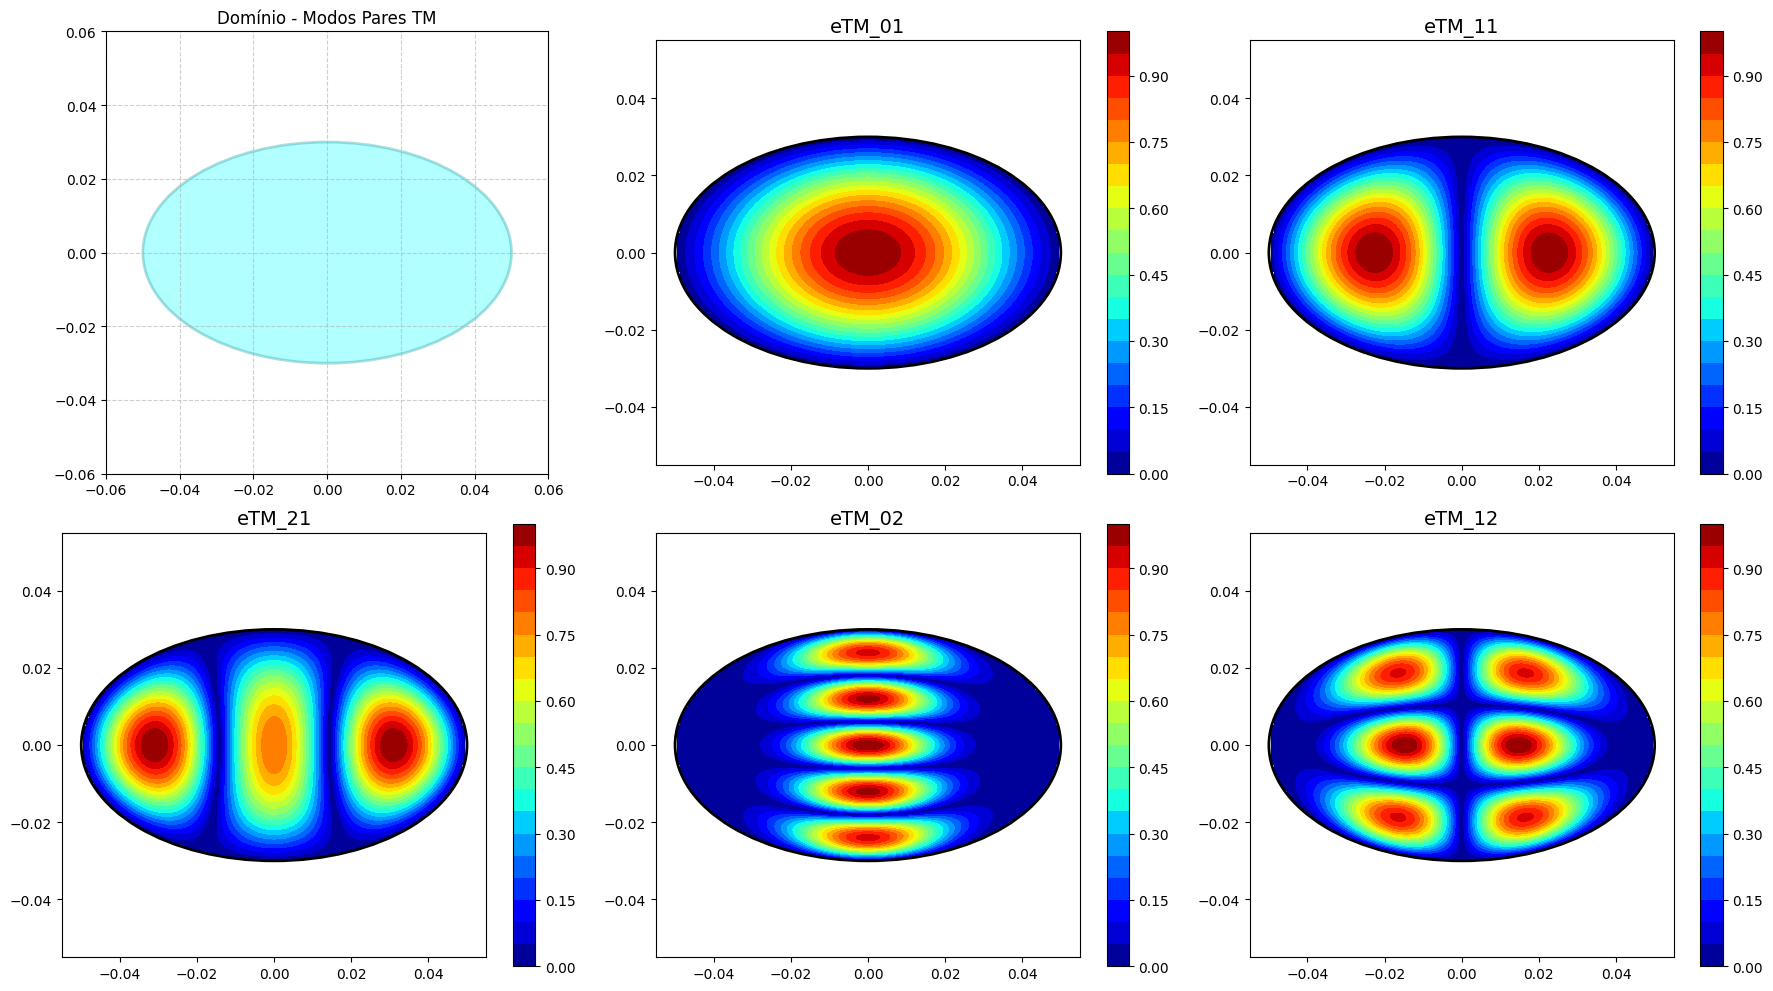

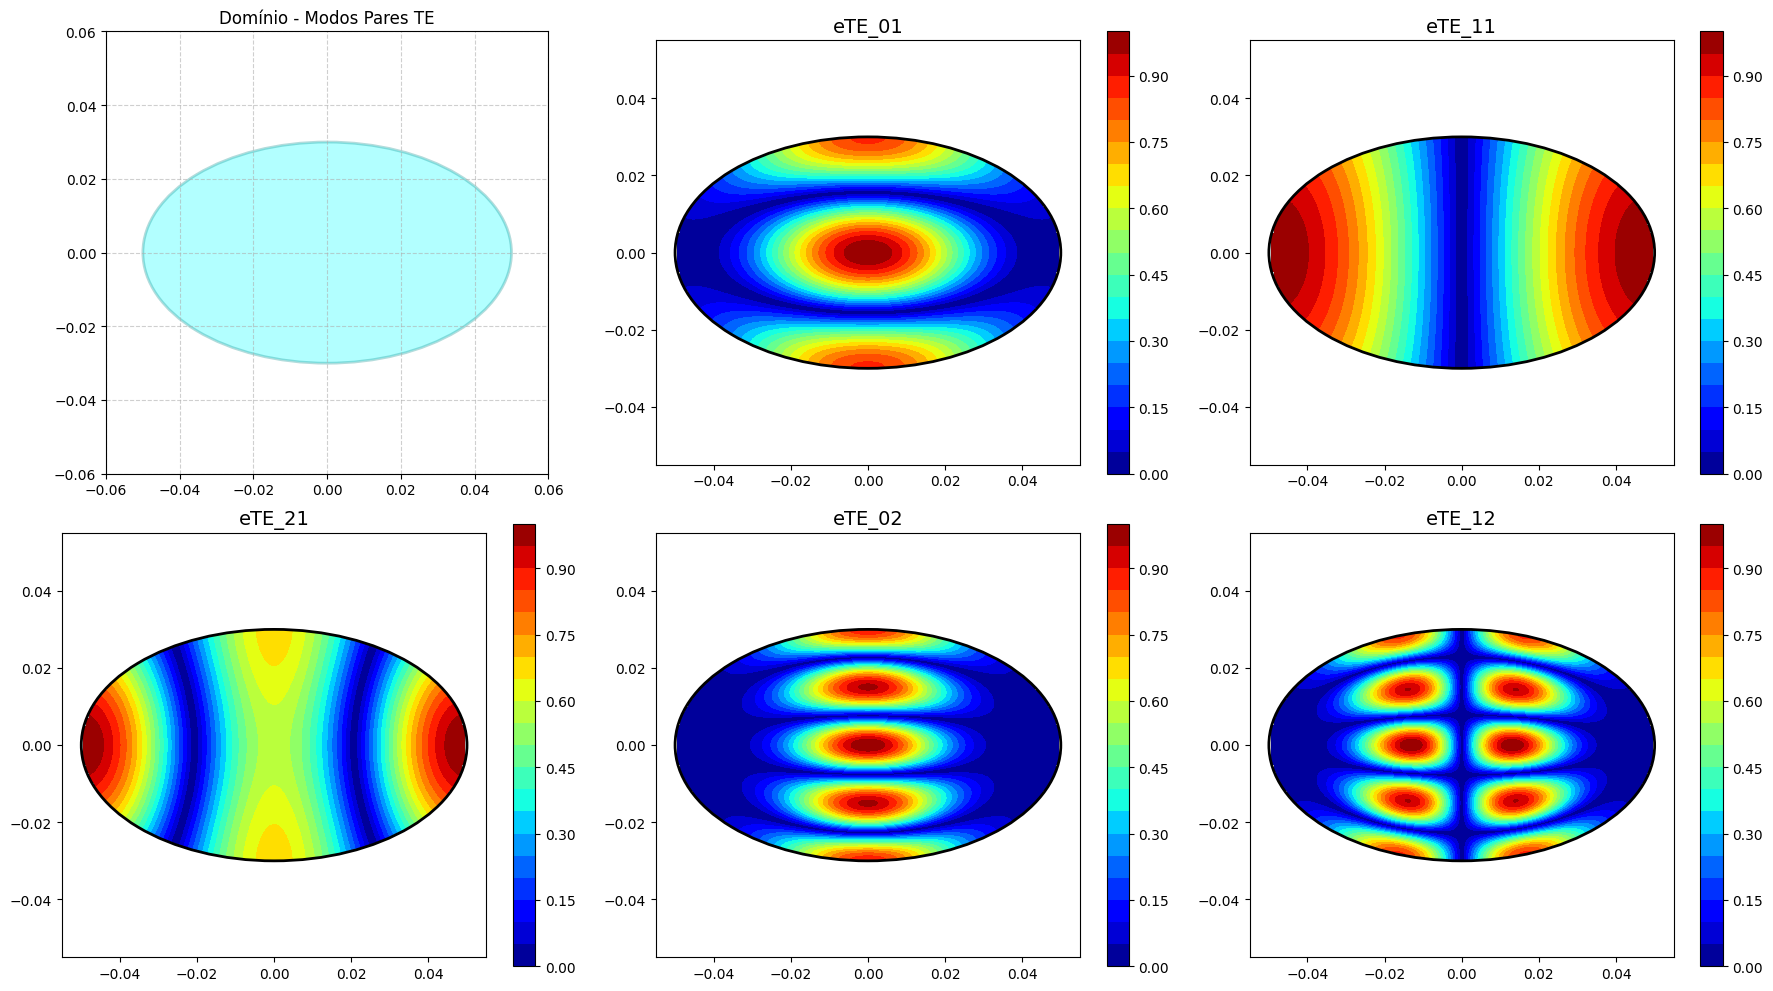

In [ ]:
# 1. Definições da Seção Elíptica
# O semi-eixo a (largura) DEVE ser maior que b (altura)
a_cm = 5.0  # Semi-eixo maior
b_cm = 3.0  # Semi-eixo menor
er_val = 1.0

secao_elip = SecaoEliptica2D(a=a_cm * sc.centi, b=b_cm * sc.centi, er=er_val)

# 2. Renderizando os painéis (Pode demorar uns segundos devido ao solver de raízes)
plotar_painel_modos_elipticos(secao_elip, tipo_modo='TM')
plotar_painel_modos_elipticos(secao_elip, tipo_modo='TE') 